# Park Task
We set up 2 actions that will differ in *yaw angle* and *required force*. \
The actions are:
- Discrete action: pull left at +5˚, Continuous kinematics: force 3g (peak)
- Discrete action: pull right at -15˚, Continuous kinematics: force 12g (peak)

We produce beta distributions from the range 1 - 15g. One bundle peaks at 3g (pull left) and another at 12g (pull right). 
We encode these distributions as 512D bundle vectors. 

Therefore, we have:
- 2 action channels: pull left vs. pull right
- Continuous action parameter (force): 3g (peak for pull left) and 12g (peak for pull right)

We create a 2x2 action grid experimental design 
|Left| Right|
|---|---|
|L @ 3g | R @ 12g|
|L @ 12g| R @ 3g|



In this case, we will have 2 discrete channels - left and right. \
Each channel will have a continous action space over the force domain [0, 15]g. \
The distribution over the left channel will have bumps/peaks at 3g and 12g. \
The distribution over the right channel will have bumps/peaks at 3g and 12g. \\

4 trials with 2 channels for left and right:
1. L3 vs. R12 - L3 is the winning channel 
2. L3 vs. R12 - R12 is the winning channel 
3. L12 vs. R3 - L12 is the winning channel 
4. L12 vs. R3 - R3 is the winning channel 

----

# Imports

In [67]:
# Add imports 
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta
from sspspace.sspspace.encoders import RandomSSPSpace

import nengo
from nengo.network import Network
from nengo import Node, Connection

# Import the basal Ganglia model 
%load_ext autoreload
%autoreload 2
from bg_model import BasalGanglia
%load_ext autoreload
%autoreload 2
from utility import Utility, ActionIterator

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Create Distributions & Bundles 

In [68]:
# ================================================
# 1. Define continuous force domain & SSP encoder
# ================================================
n_actions_park = 2
domain_force_park = np.arange(0, 15, 0.01).reshape(-1, 1) # Shape: (1500, 1)
ssp_dim_park = 512

# SSP encoder for scalar force values
ssp_encoder_park = RandomSSPSpace(
    domain_dim=1,
    ssp_dim=ssp_dim_park,
    rng=np.random.RandomState(0),
    length_scale=0.5
)
# Convert domain values to high-dimensional SSPs
domain_phis_park = ssp_encoder_park.encode(domain_force_park)  # shape: (1500, 512)
# print(domain_phis.shape)

# Place cell encoders for Nengo ensembles
low = 0
high = 15
width = high - low
places_park = np.arange(low, high, width/(domain_force_park.shape[0]))
dnf_encoders_park = np.asarray(ssp_encoder_park.encode(places_park.reshape(-1, 1))).squeeze() # Shape: (1500, 512)
# print(dnf_encoders.shape) # (512, 1500)

# ================================================
# 2. DNF Parameters
# ================================================
dnf_params_park = {
            'h'       : -3.009416816439706,
            'global_inh'      : 8.641108231311897,
            'tau'             : 0.04706404390267922,
            'exc'             : 9.421285790349613,
            'inh'             : 1.4841093480380807,
            'exc_w'           : 8.534993467227224,
            'inh_w'           : 4.748154014869723,
            'dt'              : 0.001, 
            'c_noise'         : 1.0,
            'shape'           : [(n_actions_park, 1500)], 
            'beta'            : 4,
    }


# ================================================
# 3. Generate two bundle vectors via Beta PDFs
#    Peaked at 3g and 12g respectively
# ================================================
# Beta shapes chosen so mode(a-1)/(a+b-2) matches desired peak/domain
scale = 15
# 1. Choose 4 random peak heights 
peak_heights = np.random.uniform(low=0.1, high=1.0, size=4) 
# 2. Make left and right distribution with peaks at 3 and 12
# Trick: α controls skew toward right, β toward left
# For left channel 
l3 = beta.pdf(domain_force_park, 2, 5, scale=scale) # peak at 3
l12 = beta.pdf(domain_force_park, 5, 2, scale=scale) # peak at 12
# For right channel
r3 = beta.pdf(domain_force_park, 2, 5, scale=scale) # peak at 3
r12 = beta.pdf(domain_force_park, 5, 2, scale=15) # peak at 12

distributions = [l3, l12, r3, r12]

# Combine them
# y = peak1 + peak2
# normalize > scale by saliece > combine the peaks > bundle 

# ========================================
# 4. Salience values for actions
# ========================================
# Trial 1: [L3, L12, R3, R12] - L3 wins
salience_t1 = [0.93, 0.22, 0.55, 0.61]
# Trial 2: [L3, L12, R3, R12] - L12 wins
salience_t2 = [0.25, 0.95, 0.5, 0.63]
# Trial 3: [L3, L12, R3, R12] - R3 wins
salience_t3 = [0.45, 0.62, 0.98, 0.33]
# Trial 4: [L3, L12, R3, R12] - R12 wins
salience_t4 = [0.50, 0.65, 0.40, 0.93]


# ========================================
# 5. Create bundles for the 4 sets of trials 
# ========================================
# Trial 1:
trial1 = Utility.to_bundle(Utility.to_bimodal(Utility.to_scale(salience_t1, Utility.to_normalize(distributions))), domain_phis_park)
# Trial 2: 
trial2 = Utility.to_bundle(Utility.to_bimodal(Utility.to_scale(salience_t2, Utility.to_normalize(distributions))), domain_phis_park)
# Trial 2: 
trial3 = Utility.to_bundle(Utility.to_bimodal(Utility.to_scale(salience_t3, Utility.to_normalize(distributions))), domain_phis_park)
# Trial 2: 
trial4 = Utility.to_bundle(Utility.to_bimodal(Utility.to_scale(salience_t3, Utility.to_normalize(distributions))), domain_phis_park)
# All trials
trials = [trial1, trial2, trial3, trial4]


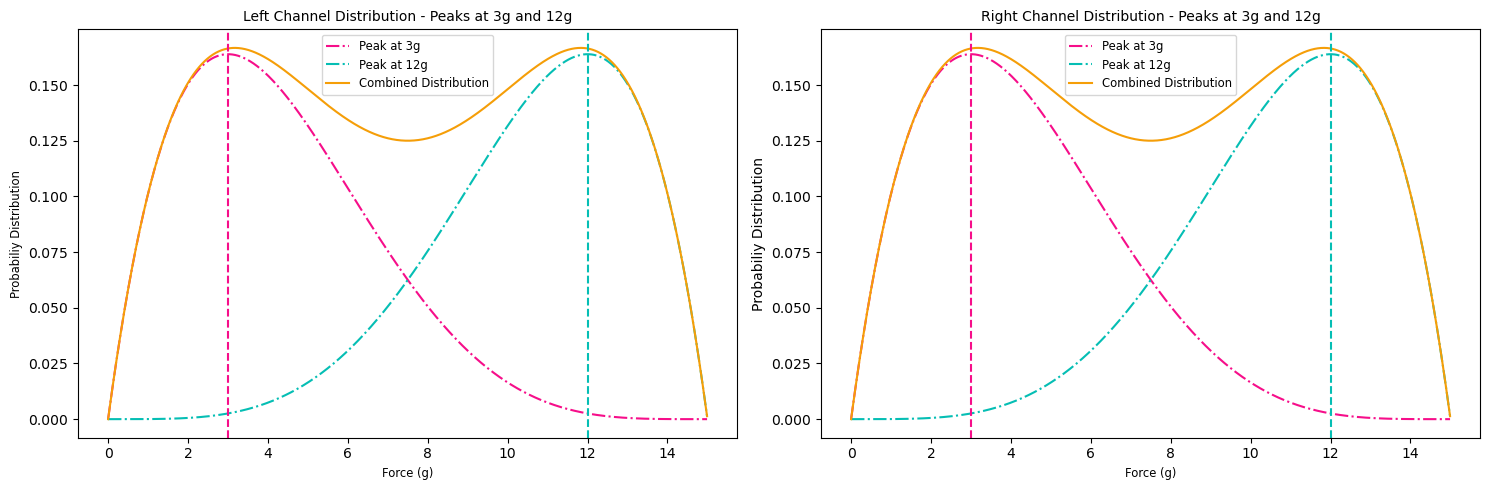

In [69]:
# ========================================
# 6. Plot the Beta distributions for each channel
# ========================================
# Plot the left and right distributions 
fig1, axes1 = plt.subplots(1, 2, figsize=(15, 5))
# -------------------------------
# Plot the Left distribution 
# ---------------------------
left = l3 + l12 # combined bimodal
axes1[0].plot(domain_force_park, l3, color="#f60c89fd", linestyle='-.', label='Peak at 3g')
axes1[0].plot(domain_force_park, l12, color="#05beb4", linestyle='-.', label='Peak at 12g')
axes1[0].plot(domain_force_park, left, color="#f59e08", label='Combined Distribution')
axes1[0].axvline(x=3, linestyle='--', color="#f60c89fd")
axes1[0].axvline(x=12, linestyle='--', color="#05beb4")
axes1[0].legend(loc='best', fontsize='small')
axes1[0].set_title("Left Channel Distribution - Peaks at 3g and 12g", fontsize='medium')
axes1[0].set_xlabel("Force (g)", fontsize='small')
axes1[0].set_ylabel("Probabiliy Distribution", fontsize='small')
# -------------------------------
# Plot the Right distribution 
# ---------------------------
right = r3 + r12 # combined bimodal
axes1[1].plot(domain_force_park, r3, color="#f60c89fd", linestyle='-.', label='Peak at 3g')
axes1[1].plot(domain_force_park, r12, color="#05beb4", linestyle='-.', label='Peak at 12g')
axes1[1].plot(domain_force_park, right, color="#f59e08", label='Combined Distribution')
axes1[1].axvline(x=3, linestyle='--', color="#f60c89fd")
axes1[1].axvline(x=12, linestyle='--', color="#05beb4")
axes1[1].legend(loc='best', fontsize='small')
axes1[1].set_title("Right Channel Distribution - Peaks at 3g and 12g", fontsize='medium')
axes1[1].set_xlabel("Force (g)", fontsize='small')
axes1[1].set_ylabel("Probabiliy Distribution")

plt.tight_layout()
plt.savefig('./figures/park/bimodal/distribution.png')
plt.show()


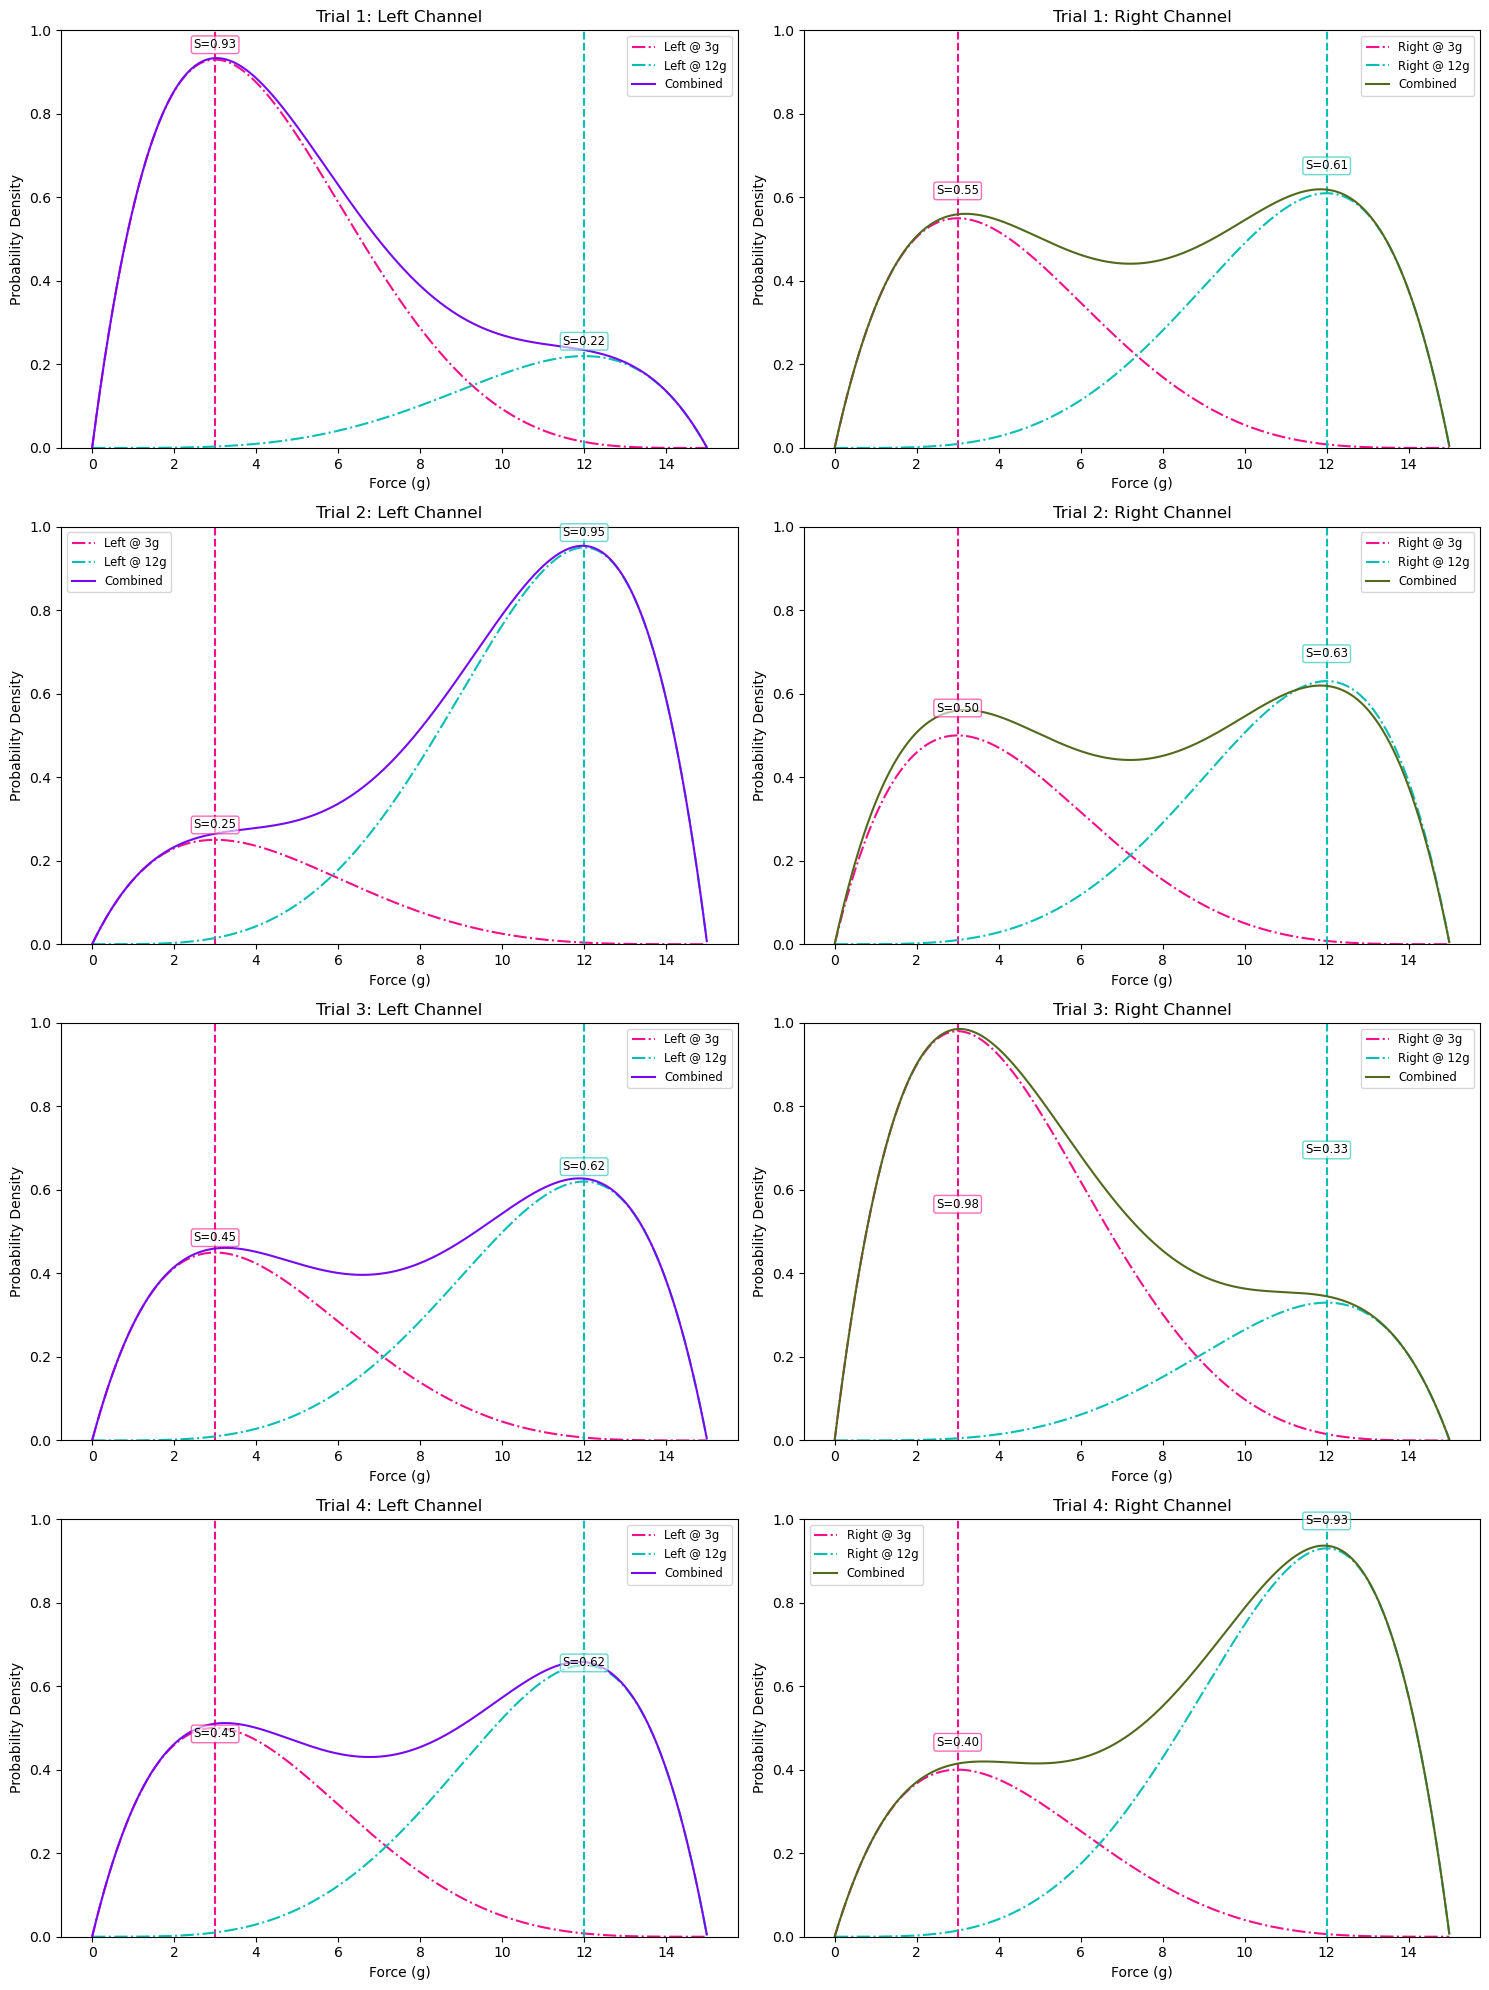

In [73]:
# ========================================
# 7. Plot the salience scaled beta distribution for each channel
# ========================================
colors = ["#f60c89fd", "#05beb4"]
actions_left = ['Left @ 3g', 'Left @ 12g']
actions_right = ['Right @ 3g', 'Right @ 12g']
peak = [3, 12]

# create 4×2 grid of subplots
fig, axes = plt.subplots(4, 2, figsize=(15, 20),)

# ---------------------------------
# Trial 1: L3 vs. R12 - L3 wins!
# ---------------------------------
# (0,0): Left
t1_left = Utility.to_scale(salience=salience_t1[:2], normalized_distributions=Utility.to_normalize([l3, l12]))
scaled_left1 = t1_left[0] + t1_left[1]
for i, pdf in enumerate(t1_left):
    axes[0, 0].plot(domain_force_park, pdf, color=colors[i],
                    label=f'{actions_left[i]}', linestyle='-.')
    axes[0, 0].axvline(x=peak[i], color=colors[i], linestyle='--')
    # Add label for peak height
    axes[0, 0].text(
        peak[i], salience_t1[i] + 0.02,   # place just above peak
        f"S={salience_t1[i]:.2f}",
        ha='center', va='bottom', fontsize='small',
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=colors[i], alpha=0.6))
axes[0, 0].plot(domain_force_park, scaled_left1, color="#7609f2", label="Combined")
axes[0, 0].set_title('Trial 1: Left Channel', fontsize='large')
axes[0, 0].set_xlabel('Force (g)')
axes[0, 0].set_ylabel("Probability Density")
axes[0, 0].set_ylim(0, 1.0)
axes[0, 0].legend(fontsize='small')

# (0,1): Right
t1_right = Utility.to_scale(salience=salience_t1[2:], normalized_distributions=Utility.to_normalize([r3, r12]))
scaled_right1 = t1_right[0] + t1_right[1]
for j, pdf in enumerate(t1_right):
    idx = j + 2   # salience indices for right channel
    axes[0, 1].plot(domain_force_park, pdf, color=colors[j],
                    label=f'{actions_right[j]}', linestyle='-.')
    axes[0, 1].axvline(x=peak[j], color=colors[j], linestyle='--')
    # Add label for peak height
    axes[0, 1].text(
        peak[j], salience_t1[idx] + 0.05,
        f"S={salience_t1[idx]:.2f}",
        ha='center', va='bottom', fontsize='small',
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=colors[j], alpha=0.6))
axes[0, 1].plot(domain_force_park, scaled_right1, color="#52681D", label="Combined")
axes[0, 1].set_title('Trial 1: Right Channel', fontsize='large')
axes[0, 1].set_xlabel('Force (g)')
axes[0, 1].set_ylabel('Probability Density')
axes[0, 1].set_ylim(0, 1.0)
axes[0, 1].legend(fontsize='small')


# ------------------------
# Trial 2: L3 vs. R12 - R12 wins!
# -----------------------
# (1, 0): Left
t2_left = Utility.to_scale(salience=salience_t2[:2], normalized_distributions=Utility.to_normalize([l3, l12]))
scaled_left2 = t2_left[0] + t2_left[1]
for i, pdf in enumerate(t2_left):
    axes[1, 0].plot(domain_force_park, pdf, color=colors[i],
                    label=f'{actions_left[i]}', linestyle='-.')
    axes[1, 0].axvline(x=peak[i], color=colors[i], linestyle='--')
    # Add label for peak height
    axes[1, 0].text(
        peak[i], salience_t2[i] + 0.02,   # place just above peak
        f"S={salience_t2[i]:.2f}",
        ha='center', va='bottom', fontsize='small',
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=colors[i], alpha=0.6))
axes[1, 0].plot(domain_force_park, scaled_left2, color="#7609f2", label="Combined")
axes[1, 0].set_title('Trial 2: Left Channel', fontsize='large')
axes[1, 0].set_xlabel('Force (g)')
axes[1, 0].set_ylabel("Probability Density")
axes[1, 0].set_ylim(0, 1.0)
axes[1, 0].legend(fontsize='small')

# (1, 1): Right
t2_right = Utility.to_scale(salience=salience_t2[2:], normalized_distributions=Utility.to_normalize([r3, r12]))
scaled_right2 = t2_right[0] + t2_right[1]
for j, pdf in enumerate(t2_right):
    idx = j + 2   # salience indices for right channel
    axes[1, 1].plot(domain_force_park, pdf, color=colors[j],
                   label=f'{actions_right[j]}', linestyle='-.')
    axes[1, 1].axvline(x=peak[j], color=colors[j], linestyle='--')
    # Add label for peak height
    axes[1, 1].text(
        peak[j], salience_t2[idx] + 0.05,
        f"S={salience_t2[idx]:.2f}",
        ha='center', va='bottom', fontsize='small',
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=colors[j], alpha=0.6))
axes[1, 1].plot(domain_force_park, scaled_right1, color="#52681D", label="Combined")
axes[1, 1].set_title('Trial 2: Right Channel', fontsize='large')
axes[1, 1].set_xlabel('Force (g)')
axes[1, 1].set_ylabel('Probability Density')
axes[1, 1].set_ylim(0, 1.0)
axes[1, 1].legend(fontsize='small')

# ------------------------
# Trial 3: L12 vs. R3 - L12 wins!
# -----------------------
# (2, 0): Left
t3_left = Utility.to_scale(salience=salience_t3[:2], normalized_distributions=Utility.to_normalize([l3, l12]))
scaled_left3 = t3_left[0] + t3_left[1]
for i, pdf in enumerate(t3_left):
    axes[2, 0].plot(domain_force_park, pdf, color=colors[i], label=f'{actions_left[i]}', linestyle='-.')
    axes[2, 0].axvline(x=peak[i], color=colors[i], linestyle='--')
    # Add label for peak height
    axes[2, 0].text(
        peak[i], salience_t3[i] + 0.02,   # place just above peak
        f"S={salience_t3[i]:.2f}",
        ha='center', va='bottom', fontsize='small',
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=colors[i], alpha=0.6))
axes[2, 0].plot(domain_force_park, scaled_left3, color="#7609f2", label="Combined")
axes[2, 0].set_title('Trial 3: Left Channel', fontsize='large')
axes[2, 0].set_xlabel('Force (g)')
axes[2, 0].set_ylabel("Probability Density")
axes[2, 0].set_ylim(0, 1.0)
axes[2, 0].legend(fontsize='small')

# # (2, 1): Right
t3_right = Utility.to_scale(salience=salience_t3[2:], normalized_distributions=Utility.to_normalize([r3, r12]))
scaled_right3 = t3_right[0] + t3_right[1]
for j, pdf in enumerate(t3_right):
    idx = j + 2   # salience indices for right channel
    axes[2, 1].plot(domain_force_park, pdf, color=colors[j],
                   label=f'{actions_right[j]}', linestyle='-.')
    axes[2, 1].axvline(x=peak[j], color=colors[j], linestyle='--')
    # Add label for peak height
    axes[2, 1].text(
        peak[j], salience_t2[idx] + 0.05,
        f"S={salience_t3[idx]:.2f}",
        ha='center', va='bottom', fontsize='small',
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=colors[j], alpha=0.6))
axes[2, 1].plot(domain_force_park, scaled_right3, color="#52681D", label="Combined")
axes[2, 1].set_title('Trial 3: Right Channel', fontsize='large')
axes[2, 1].set_xlabel('Force (g)')
axes[2, 1].set_ylabel('Probability Density')
axes[2, 1].set_ylim(0, 1.0)
axes[2, 1].legend(fontsize='small')

# ------------------------
# Trial 4: L12 vs. R3 - R3 wins!
# -----------------------
# (3, 0): Left
t4_left = Utility.to_scale(salience=salience_t4[:2], normalized_distributions=Utility.to_normalize([l3, l12]))
scaled_left4 = t4_left[0] + t4_left[1]
for i, pdf in enumerate(t4_left):
    axes[3, 0].plot(domain_force_park, pdf, color=colors[i], label=f'{actions_left[i]}', linestyle='-.')
    axes[3, 0].axvline(x=peak[i], color=colors[i], linestyle='--')
    # Add label for peak height
    axes[3, 0].text(
        peak[i], salience_t3[i] + 0.02,   # place just above peak
        f"S={salience_t3[i]:.2f}",
        ha='center', va='bottom', fontsize='small',
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=colors[i], alpha=0.6))
axes[3, 0].plot(domain_force_park, scaled_left4, color="#7609f2", label="Combined")
axes[3, 0].set_title('Trial 4: Left Channel', fontsize='large')
axes[3, 0].set_xlabel('Force (g)')
axes[3, 0].set_ylabel("Probability Density")
axes[3, 0].set_ylim(0, 1.0)
axes[3, 0].legend(fontsize='small')

# # (2, 1): Right
t4_right = Utility.to_scale(salience=salience_t4[2:], normalized_distributions=Utility.to_normalize([r3, r12]))
scaled_right4 = t4_right[0] + t4_right[1]
for j, pdf in enumerate(t4_right):
    idx = j + 2   # salience indices for right channel
    axes[3, 1].plot(domain_force_park, pdf, color=colors[j],
                   label=f'{actions_right[j]}', linestyle='-.')
    axes[3, 1].axvline(x=peak[j], color=colors[j], linestyle='--')
    # Add label for peak height
    axes[3, 1].text(
        peak[j], salience_t4[idx] + 0.05,
        f"S={salience_t4[idx]:.2f}",
        ha='center', va='bottom', fontsize='small',
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=colors[j], alpha=0.6))
axes[3, 1].plot(domain_force_park, scaled_right4, color="#52681D", label="Combined")
axes[3, 1].set_title('Trial 4: Right Channel', fontsize='large')
axes[3, 1].set_xlabel('Force (g)')
axes[3, 1].set_ylabel('Probability Density')
axes[3, 1].set_ylim(0, 1.0)
axes[3, 1].legend(fontsize='small')

plt.tight_layout()
plt.savefig('./figures/park/bimodal/trial_distribution.png')
plt.show()

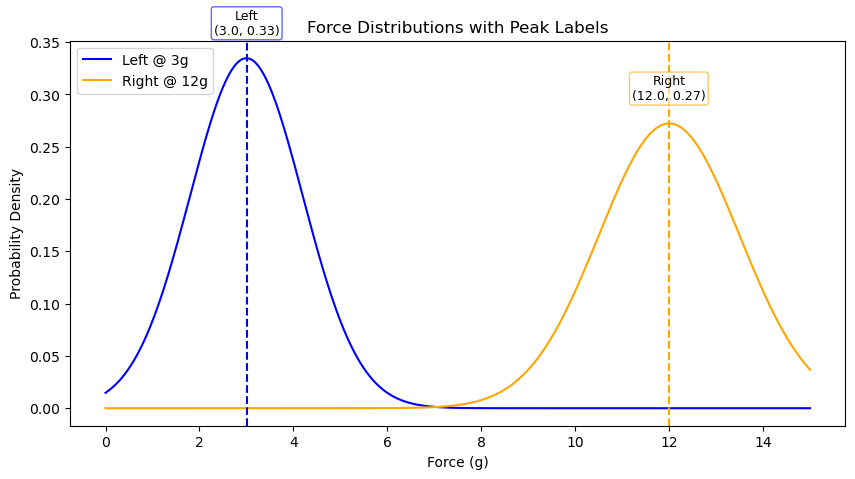

In [71]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, 15, 500)
# Example distributions
left_pdf = np.exp(-0.5*((x-3)/1.2)**2)
right_pdf = np.exp(-0.5*((x-12)/1.5)**2)
left_pdf /= np.trapz(left_pdf, x)
right_pdf /= np.trapz(right_pdf, x)

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(x, left_pdf, color="blue", label="Left @ 3g")
ax.plot(x, right_pdf, color="orange", label="Right @ 12g")

# --- Find and mark peaks ---
for pdf, color, label in [(left_pdf, "blue", "Left"), (right_pdf, "orange", "Right")]:
    peak_idx = np.argmax(pdf)
    x_peak, y_peak = x[peak_idx], pdf[peak_idx]
    ax.axvline(x_peak, color=color, linestyle="--")
    ax.text(
        x_peak, y_peak + 0.02,               # just above the peak
        f"{label}\n({x_peak:.1f}, {y_peak:.2f})", 
        ha="center", va="bottom", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=color, alpha=0.6)
    )

ax.set_xlabel("Force (g)")
ax.set_ylabel("Probability Density")
ax.set_title("Force Distributions with Peak Labels")
ax.legend()
plt.show()
